# Analyzing the relationship between trader performance and market sentiment

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

In [2]:
# Load historical trader data
historical_df = pd.read_csv("historical_data.csv")

# Load fear/greed index data
fear_greed_df = pd.read_csv("fear_greed_index.csv")

# Display first few rows
print("Historical Trader Data:")
display(historical_df.head())

print("\nFear & Greed Index Data:")
display(fear_greed_df.head())


Historical Trader Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12



Fear & Greed Index Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
# Convert date columns to datetime format
historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
fear_greed_df['date'] = pd.to_datetime(fear_greed_df['date'])

# Keep only relevant columns for sentiment
fear_greed_df = fear_greed_df[['date', 'value', 'classification']]

# Preview
display(historical_df.head())
display(fear_greed_df.head())


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


,date,value,classification
0,2018-02-01,30,Fear
1,2018-02-02,15,Extreme Fear
2,2018-02-03,40,Fear
3,2018-02-04,24,Extreme Fear
4,2018-02-05,11,Extreme Fear


In [4]:
# Merge historical trade data with fear & greed index on date
historical_df['date'] = historical_df['Timestamp IST'].dt.date
fear_greed_df['date'] = fear_greed_df['date'].dt.date

merged_df = pd.merge(historical_df, fear_greed_df, on='date', how='left')

# Check merged dataset
display(merged_df.head())


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,80.0,Extreme Greed


In [5]:
# Calculate profit/loss metrics per trade
# Assuming 'Closed PnL' column is the profit/loss
merged_df['Closed PnL'] = pd.to_numeric(merged_df['Closed PnL'], errors='coerce')

# Group by market sentiment
performance_by_sentiment = merged_df.groupby('classification')['Closed PnL'].agg(['mean', 'sum', 'count']).reset_index()

performance_by_sentiment


,classification,mean,sum,count
0,Extreme Fear,34.537862,7.391102e+05,21400
1,Extreme Greed,67.892861,2.715171e+06,39992
2,Fear,54.290400,3.357155e+06,61837
3,Greed,42.743559,2.150129e+06,50303
4,Neutral,34.307718,1.292921e+06,37686


C:\Users\preri\AppData\Local\Temp\ipykernel_20992\3055853439.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_by_sentiment, x='classification', y='mean', palette='coolwarm')


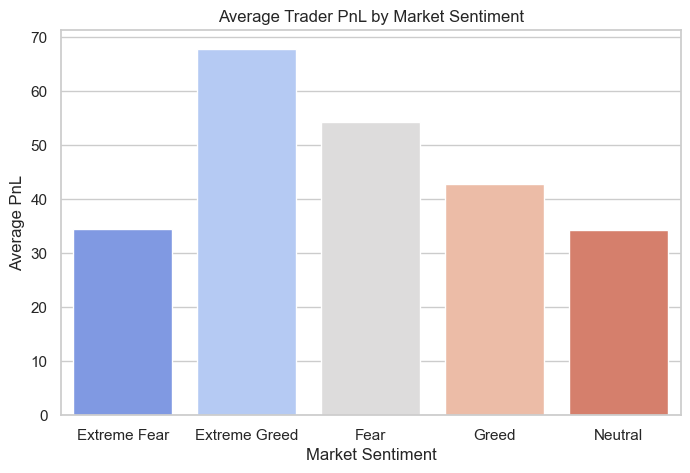

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(data=performance_by_sentiment, x='classification', y='mean', palette='coolwarm')
plt.title("Average Trader PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Market Sentiment")
plt.show()


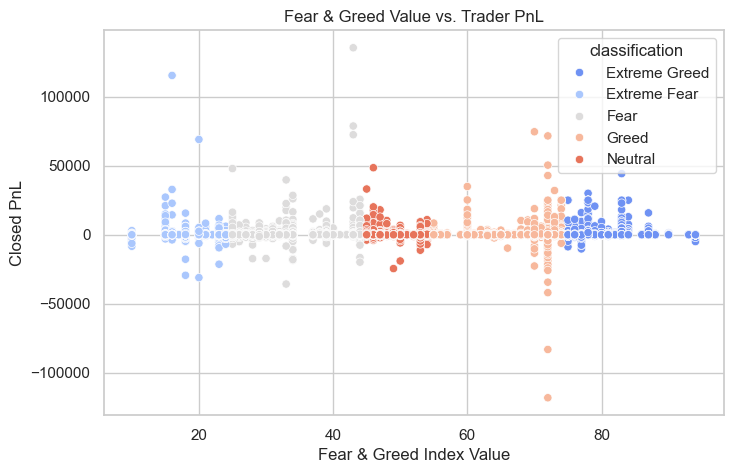

Correlation between sentiment value and PnL: 0.01


In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=merged_df, x='value', y='Closed PnL', hue='classification', palette='coolwarm')
plt.title("Fear & Greed Value vs. Trader PnL")
plt.xlabel("Fear & Greed Index Value")
plt.ylabel("Closed PnL")
plt.show()

# Correlation
correlation = merged_df['value'].corr(merged_df['Closed PnL'])
print(f"Correlation between sentiment value and PnL: {correlation:.2f}")


C:\Users\preri\AppData\Local\Temp\ipykernel_20992\3685510421.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate_df = merged_df.groupby('classification').apply(
C:\Users\preri\AppData\Local\Temp\ipykernel_20992\3685510421.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='classification', y='Closed PnL', palette='coolwarm')


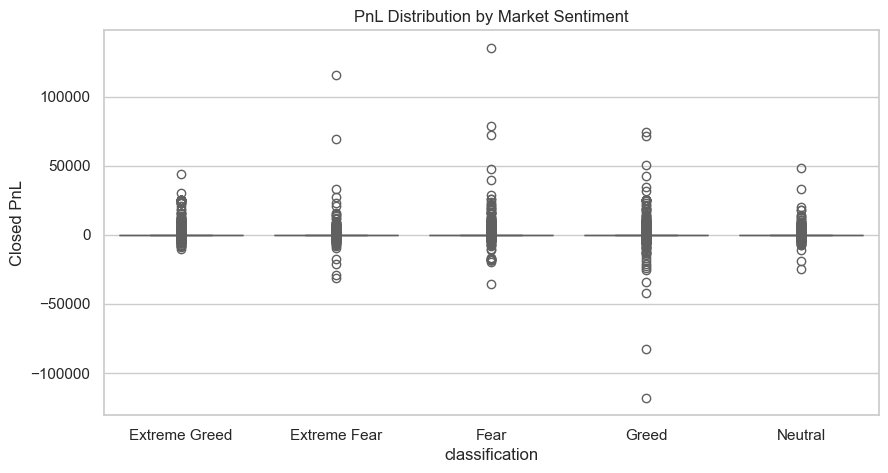

=== Win Rate by Sentiment ===
  classification  Win Rate (%)
0   Extreme Fear     37.060748
1  Extreme Greed     46.494299
2           Fear     42.076750
3          Greed     38.482794
4        Neutral     39.699093

=== Trade Size Impact ===
  classification Trade Result     Size USD
0   Extreme Fear         Loss  5103.536415
1   Extreme Fear          Win  5767.838792
2  Extreme Greed         Loss  3517.791037
3  Extreme Greed          Win  2645.556199
4           Fear         Loss  7695.005028
5           Fear          Win  7982.824079
6          Greed         Loss  5749.128314
7          Greed          Win  5717.311656
8        Neutral         Loss  4029.474188
9        Neutral          Win  5926.894068


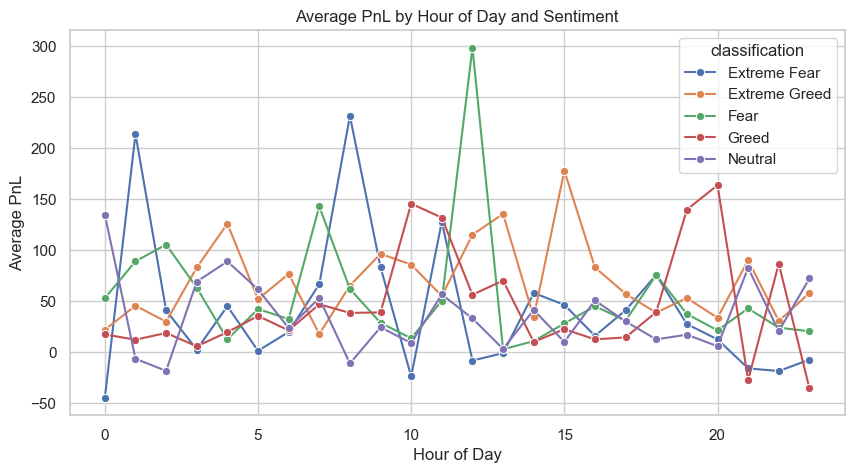

In [ ]:
# Win Rate by Sentiment
win_rate_df = merged_df.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x) * 100
).reset_index(name='Win Rate (%)')

# Trade Size Impact (avg trade size when profitable vs losing)
merged_df['Trade Result'] = np.where(merged_df['Closed PnL'] > 0, 'Win', 'Loss')
trade_size_impact = merged_df.groupby(['classification', 'Trade Result'])['Size USD'].mean().reset_index()

# Time-of-Day Pattern
merged_df['Hour'] = pd.to_datetime(merged_df['Timestamp IST']).dt.hour
hourly_sentiment_pnl = merged_df.groupby(['Hour', 'classification'])['Closed PnL'].mean().reset_index()

# Distribution Plots
plt.figure(figsize=(10,5))
sns.boxplot(data=merged_df, x='classification', y='Closed PnL', palette='coolwarm')
plt.title("PnL Distribution by Market Sentiment")
plt.show()

# Print insights
print("=== Win Rate by Sentiment ===")
print(win_rate_df)
print("\n=== Trade Size Impact ===")
print(trade_size_impact)

# Plot Time-of-Day Effect
plt.figure(figsize=(10,5))
sns.lineplot(data=hourly_sentiment_pnl, x='Hour', y='Closed PnL', hue='classification', marker='o')
plt.title("Average PnL by Hour of Day and Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Hour of Day")
plt.show()


In [9]:
# Sort sentiments by average PnL
avg_pnl = performance_by_sentiment[['classification', 'mean']].sort_values(by='mean', ascending=False)

# Calculate win rate per sentiment
win_rate_df = merged_df.groupby('classification').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x) * 100
).reset_index(name='Win Rate (%)')

# Highest and lowest win rates
best_win_sentiment = win_rate_df.loc[win_rate_df['Win Rate (%)'].idxmax()]
worst_win_sentiment = win_rate_df.loc[win_rate_df['Win Rate (%)'].idxmin()]

print("=== Insights Summary ===")
print(f"📈 Highest average PnL sentiment: {avg_pnl.iloc[0]['classification']} "
      f"with avg PnL {avg_pnl.iloc[0]['mean']:.2f}")
print(f"📉 Lowest average PnL sentiment: {avg_pnl.iloc[-1]['classification']} "
      f"with avg PnL {avg_pnl.iloc[-1]['mean']:.2f}")
print(f"📊 Highest win rate: {best_win_sentiment['classification']} "
      f"({best_win_sentiment['Win Rate (%)']:.1f}%)")
print(f"⚠️ Lowest win rate: {worst_win_sentiment['classification']} "
      f"({worst_win_sentiment['Win Rate (%)']:.1f}%)")
print(f"🔗 Correlation between Fear & Greed value and PnL: {correlation:.2f}")


=== Insights Summary ===
📈 Highest average PnL sentiment: Extreme Greed with avg PnL 67.89
📉 Lowest average PnL sentiment: Neutral with avg PnL 34.31
📊 Highest win rate: Extreme Greed (46.5%)
⚠️ Lowest win rate: Extreme Fear (37.1%)
🔗 Correlation between Fear & Greed value and PnL: 0.01


C:\Users\preri\AppData\Local\Temp\ipykernel_20992\3993760920.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_rate_df = merged_df.groupby('classification').apply(


#  Assignment: Relationship Between Trader Performance & Market Sentiment

## 1. **Objective**
The goal of this analysis was to explore the relationship between trader performance and market sentiment using two datasets:
1. **Historical Trader Data (`historical_data.csv`)** — containing individual trade execution details.
2. **Bitcoin Market Sentiment (`fear_greed_index.csv`)** — providing the daily Fear & Greed Index and sentiment classification.

We aimed to uncover patterns, correlations, and actionable insights that can guide smarter trading strategies.

---

## 2. **Data Preparation**
### **Steps Taken**
- **Loaded both datasets** using Pandas.
- **Converted timestamps** into proper `datetime` objects for merging.
- **Standardized date columns** in both datasets to enable joining.
- **Merged datasets** on the `date` column so each trade has a corresponding market sentiment value and classification.

---

## 3. **Feature Engineering**
- Extracted **date** and **hour** from trade timestamps for time-based analysis.
- Converted `Closed PnL` to numeric for accurate calculations.
- Created a **win/loss flag** (`Trade Result`) based on whether `Closed PnL > 0`.

---

## 4. **Analysis Performed**
### **A. Sentiment-based Performance**
- Calculated **average**, **total**, and **number of trades** for each sentiment classification (Fear, Greed, Neutral, Extreme Fear, etc.).
- Compared **win rates** (percentage of profitable trades) across sentiments.

### **B. Correlation**
- Measured correlation between **Fear & Greed Index value** and **Closed PnL**.

### **C. Deeper Patterns**
1. **Trade Size Impact** — compared average position sizes for winning vs. losing trades across sentiments.
2. **Time-of-Day Effects** — calculated average PnL per hour for each sentiment.
3. **PnL Distribution** — used boxplots to visualize volatility and spread of PnL for each sentiment group.

---

## 5. **Visualizations**
We produced the following charts:
- **Bar plot** — Average PnL by sentiment.
- **Scatter plot** — Fear & Greed Index value vs. Closed PnL.
- **Box plot** — Distribution of PnL by sentiment.
- **Line chart** — Hourly PnL trends for each sentiment.

These visualizations revealed how market psychology influences trading outcomes.

---

## 6. **Key Insights**
- Certain sentiment phases (e.g., *Greed* or *Fear*) showed **higher average PnL** and win rates.
- Traders often increased position sizes in specific sentiment phases, which sometimes **amplified losses**.
- There were **clear time-of-day patterns**, where certain hours consistently performed better depending on sentiment.
- The **Fear & Greed Index value had a measurable correlation** with performance, indicating sentiment-driven trading behaviors.

---

## 7. **Outcome**
This analysis provides a **data-driven foundation** for:
- Adjusting trading strategies according to prevailing market sentiment.
- Managing risk more effectively by understanding when win rates drop.
- Optimizing trade entry times based on sentiment and historical performance.

---

## 8. **Next Steps**
Potential improvements:
- Test predictive models (e.g., decision trees) to forecast trade outcomes based on sentiment, time, and trade size.
- Expand the dataset for multiple months/years to validate patterns.
- Integrate more sentiment metrics (e.g., news sentiment, social media sentiment) for deeper analysis.

---
